<a href="https://colab.research.google.com/github/MMoeedRana/multi-dataset-data-analysis/blob/main/Assignment_DataAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data Analytics Assignment

from google.colab import files
uploaded = files.upload()

Saving Air_Quality_Data.csv to Air_Quality_Data.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Air Quality Dataset
# Data Loading & Understanding

aq = pd.read_csv('Air_Quality_Data.csv')

In [ ]:
aq.head()

,date,aqi_pm2.5,max_temp_f,avg_temp_f,min_temp_f,max_dew_point_f,avg_dew_point_f,min_dew_point_f,max_humidity_percent,avg_humidity_percent,min_humidity_percent,max_wind_speed_mph,avg_wind_speed_mph,min_wind_speed_mph,max_pressure_in,avg_pressure_in,min_pressure_in
0,1/1/2020,355.0,52,43.1,36,45,39.4,32,100,86.8,71,6,1.8,0,29.5,29.4,29.4
1,2/1/2020,375.0,63,49.2,39,46,41.9,36,93,77.1,48,7,2.2,0,29.5,28.8,0.0
2,3/1/2020,311.0,68,53.3,43,43,38.6,34,87,61.3,30,6,1.7,0,29.4,29.4,29.3
3,4/1/2020,370.0,61,51.6,41,46,41.1,37,93,69.5,45,3,0.1,0,29.4,29.3,29.3
4,5/1/2020,246.0,59,51.7,43,48,43.9,39,88,76.1,54,7,2.2,0,29.4,29.3,29.3


In [ ]:
# Data Cleaning & Preprocessing

aq['date'] = pd.to_datetime(aq['date'], format='mixed')

In [ ]:
aq['date']

,date
0,2020-01-01
1,2020-02-01
2,2020-03-01
3,2020-04-01
4,2020-05-01
...,...
1425,2023-11-26
1426,2023-11-27
1427,2023-11-28
1428,2023-11-29


In [ ]:
aq.drop_duplicates(inplace=True)

In [ ]:
aq['aqi_pm2.5'] = aq['aqi_pm2.5'].fillna(aq['aqi_pm2.5'].median())

In [ ]:
aq['aqi_pm2.5']

,aqi_pm2.5
0,355.0
1,375.0
2,311.0
3,370.0
4,246.0
...,...
1425,365.0
1426,378.0
1427,358.0
1428,332.0


In [ ]:
aq['Year'] = aq['date'].dt.year
aq['Month'] = aq['date'].dt.month
aq['Day'] = aq['date'].dt.day

In [ ]:
aq[['Year', 'Month', 'Day']]

,Year,Month,Day
0,2020,1,1
1,2020,2,1
2,2020,3,1
3,2020,4,1
4,2020,5,1
...,...,...,...
1425,2023,11,26
1426,2023,11,27
1427,2023,11,28
1428,2023,11,29


In [ ]:
def pollution_category(aqi):
    if aqi <= 50:
      return 'Good'
    elif aqi <= 100:
      return 'Moderate'
    elif aqi <= 150:
      return 'Unhealthy for Sensitive'
    elif aqi <= 200:
      return 'Unhealthy'
    elif aqi <= 300:
      return 'Very Unhealthy'
    else:
      return 'Hazardous'

aq['Pollution_Level'] = aq['aqi_pm2.5'].apply(pollution_category)

In [ ]:
aq['Pollution_Level']

,Pollution_Level
0,Hazardous
1,Hazardous
2,Hazardous
3,Hazardous
4,Very Unhealthy
...,...
1425,Hazardous
1426,Hazardous
1427,Hazardous
1428,Hazardous


In [ ]:
# Outliers (IQR)

Q1 = aq['aqi_pm2.5'].quantile(0.25)
Q3 = aq['aqi_pm2.5'].quantile(0.75)

In [ ]:
IQR = Q3 - Q1

In [ ]:
aq['aqi_pm2.5'] = aq['aqi_pm2.5'].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

In [ ]:
aq['aqi_pm2.5']

,aqi_pm2.5
0,303.0
1,303.0
2,303.0
3,303.0
4,246.0
...,...
1425,303.0
1426,303.0
1427,303.0
1428,303.0


In [ ]:
# Exploratory Data Analysis (EDA)

plt.figure(figsize=(10,4))

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

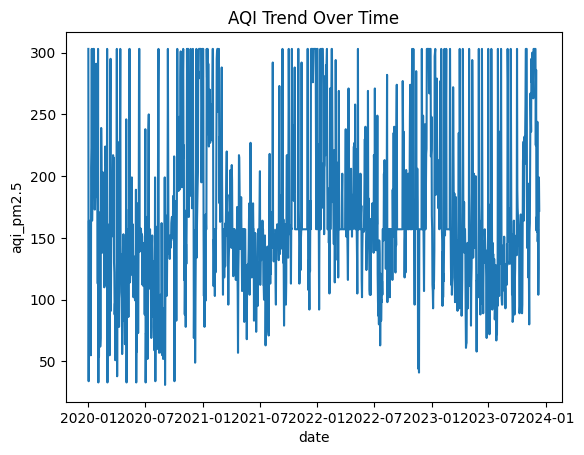

In [ ]:
sns.lineplot(x='date', y='aqi_pm2.5', data=aq)
plt.title('AQI Trend Over Time')
plt.show()

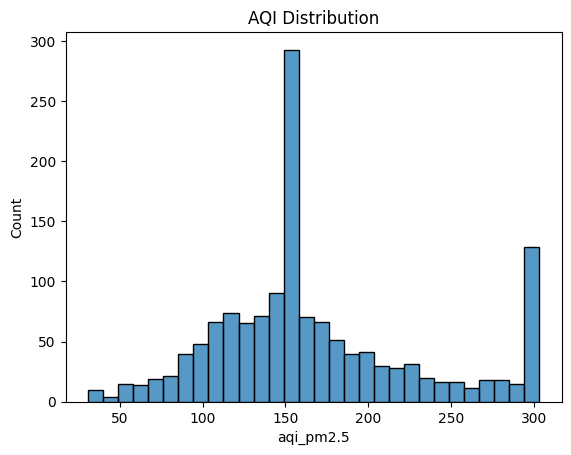

In [ ]:
sns.histplot(aq['aqi_pm2.5'], bins=30)
plt.title('AQI Distribution')
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Energy_Consumption_Data.csv to Energy_Consumption_Data.csv


In [ ]:
# Energy Consumption Dataset
# Data Loading & Understanding

eng = pd.read_csv('Energy_Consumption_Data.csv')

In [ ]:
eng.head()

,Date_Time,Usage_kW,AC_DR_kW,UPS_kW,LR_kW,Kitchen_kW,AC_Dr_kW,AC_BR_kW
0,7/15/2018 0:00,1.7310,0.0006,0.2575,0.3531,0.3518,0.0097,0.0001
1,7/15/2018 0:01,1.7415,0.0006,0.2854,0.3504,0.3485,0.0097,0.0002
2,7/15/2018 0:02,1.7391,0.0006,0.2836,0.3520,0.3477,0.0097,0.0002
3,7/15/2018 0:03,1.7371,0.0006,0.2864,0.3504,0.3466,0.0096,0.0002
4,7/15/2018 0:04,1.7268,0.0006,0.2819,0.3491,0.3464,0.0097,0.0002


In [ ]:
# Data Cleaning & Preprocessing

eng['Date_Time'] = pd.to_datetime(eng['Date_Time'], errors='coerce')

In [ ]:
eng['Date_Time']

,Date_Time
0,2018-07-15 00:00:00
1,2018-07-15 00:01:00
2,2018-07-15 00:02:00
3,2018-07-15 00:03:00
4,2018-07-15 00:04:00
...,...
462235,2019-05-31 23:55:00
462236,2019-05-31 23:56:00
462237,2019-05-31 23:57:00
462238,2019-05-31 23:58:00


In [ ]:
eng.sort_values('Date_Time', inplace=True)

In [ ]:
eng.ffill(inplace=True)
eng.drop_duplicates(inplace=True)

In [ ]:
eng.isnull().sum()

,0
Date_Time,0
Usage_kW,0
AC_DR_kW,0
UPS_kW,0
LR_kW,0
Kitchen_kW,0
AC_Dr_kW,0
AC_BR_kW,0
Year,0
Month,0


In [ ]:
# Extract Year, Month, Day, Hour
eng['Year'] = eng['Date_Time'].dt.year
eng['Month'] = eng['Date_Time'].dt.month
eng['Day'] = eng['Date_Time'].dt.day
eng['Hour'] = eng['Date_Time'].dt.hour

In [ ]:
eng[['Year', 'Month', 'Day', 'Hour']]

,Year,Month,Day,Hour
0,2018,7,15,0
1,2018,7,15,0
2,2018,7,15,0
3,2018,7,15,0
4,2018,7,15,0
...,...,...,...,...
462235,2019,5,31,23
462236,2019,5,31,23
462237,2019,5,31,23
462238,2019,5,31,23


In [ ]:
# Exploratory Data Analysis (EDA)

plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

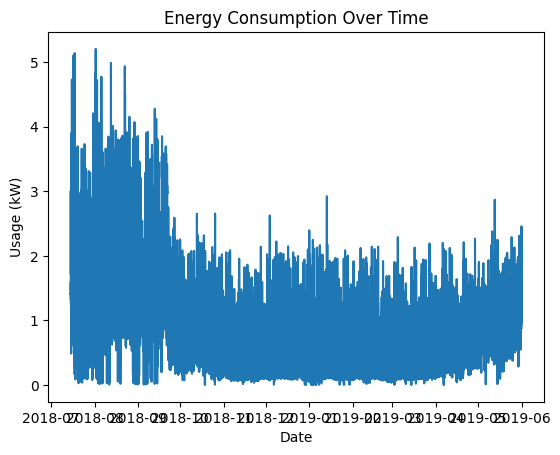

In [ ]:
sns.lineplot(x='Date_Time', y='Usage_kW', data=eng)
plt.title('Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Usage (kW)')
plt.show()

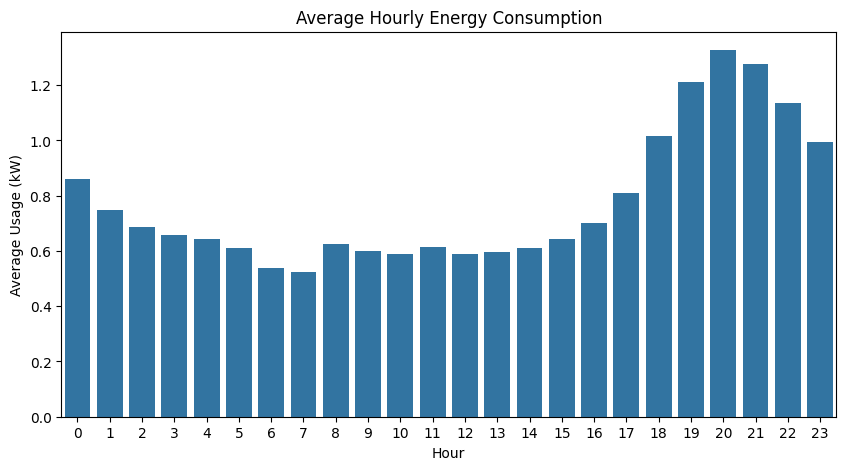

In [ ]:

# Average usage by hour

hourly_energy = eng.groupby('Hour')['Usage_kW'].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=hourly_energy.index, y=hourly_energy.values)
plt.title('Average Hourly Energy Consumption')
plt.xlabel('Hour')
plt.ylabel('Average Usage (kW)')
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Traffic_Volume_Data.csv to Traffic_Volume_Data.csv


In [ ]:
# Data Loading & Understanding

trf = pd.read_csv('Traffic_Volume_Data.csv')

In [ ]:
trf.head()

,timestamp,hour,day_of_week,is_weekend,month,vehicle_count_main,vehicle_count_secondary,avg_speed_gps,speed_variance_gps,travel_time_index,...,road_condition,weather,incident_reported,construction_zone,segment_id,congestion_value,congestion_level,congestion_lag_1,congestion_lag_2,congestion_lag_3
0,1/1/2024 0:00,0,0,0,1,120.500478,76.441739,61.930730,0.462643,1.637897,...,0,0,0,0,D,0.345860,Medium,0.34586,0.34586,0.34586
1,1/1/2024 0:05,0,0,0,1,120.243507,57.936763,71.222160,0.368382,2.034579,...,1,0,1,0,E,0.556809,Medium,0.34586,0.34586,0.34586
2,1/1/2024 0:10,0,0,0,1,123.681559,32.511210,74.318552,8.033866,3.157583,...,0,0,0,0,E,0.232830,Low,0.34586,0.34586,0.34586
3,1/1/2024 0:15,0,0,0,1,132.055214,86.635215,71.826939,1.444936,1.336955,...,2,0,0,0,D,0.137646,Low,0.34586,0.34586,0.34586
4,1/1/2024 0:20,0,0,0,1,115.098819,42.560565,49.002564,0.787953,2.934589,...,0,0,0,0,C,0.432116,Medium,0.34586,0.34586,0.34586


In [ ]:
# Data Cleaning & Preprocessing

trf['timestamp'] = pd.to_datetime(trf['timestamp'])

In [ ]:
trf['timestamp']

,timestamp
0,2024-01-01 00:00:00
1,2024-01-01 00:05:00
2,2024-01-01 00:10:00
3,2024-01-01 00:15:00
4,2024-01-01 00:20:00
...,...
17275,2024-02-29 23:35:00
17276,2024-02-29 23:40:00
17277,2024-02-29 23:45:00
17278,2024-02-29 23:50:00


In [ ]:
# Extract Year, Month, Day, Hour

trf['Year'] = trf['timestamp'].dt.year
trf['Month'] = trf['timestamp'].dt.month
trf['Day'] = trf['timestamp'].dt.day
trf['Hour'] = trf['timestamp'].dt.hour

In [ ]:
trf[['Year', 'Month', 'Day', 'Hour']]

,Year,Month,Day,Hour
0,2024,1,1,0
1,2024,1,1,0
2,2024,1,1,0
3,2024,1,1,0
4,2024,1,1,0
...,...,...,...,...
17275,2024,2,29,23
17276,2024,2,29,23
17277,2024,2,29,23
17278,2024,2,29,23


In [ ]:
# Peak vs Off-peak hours

def peak_offpeak(hour):
  if 7 <= hour >= 7 or 17 <= hour <= 20:
    return 'Peak'
  else:
    return 'Off-Peak'

trf['Peak_Hours'] = trf['Hour'].apply(peak_offpeak)

In [ ]:
trf['Peak_Hours']

,Peak_Hours
0,Off-Peak
1,Off-Peak
2,Off-Peak
3,Off-Peak
4,Off-Peak
...,...
17275,Peak
17276,Peak
17277,Peak
17278,Peak


In [ ]:
# Handle missing values (if any)

trf.ffill(inplace=True)

In [ ]:
trf.isnull().sum()

,0
timestamp,0
hour,0
day_of_week,0
is_weekend,0
month,0
vehicle_count_main,0
vehicle_count_secondary,0
avg_speed_gps,0
speed_variance_gps,0
travel_time_index,0


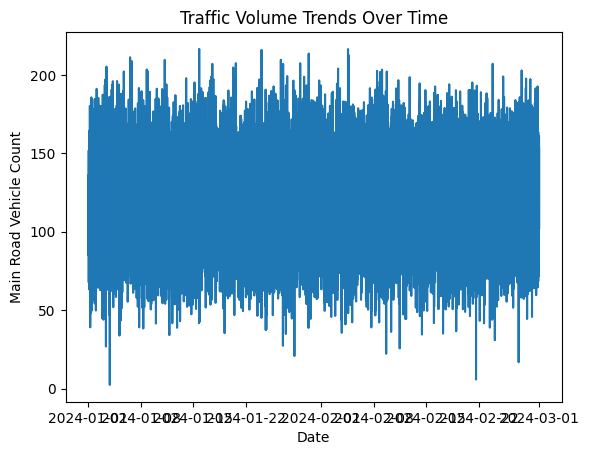

In [ ]:
sns.lineplot(x='timestamp', y='vehicle_count_main', data=trf)
plt.title('Traffic Volume Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Main Road Vehicle Count')
plt.show()

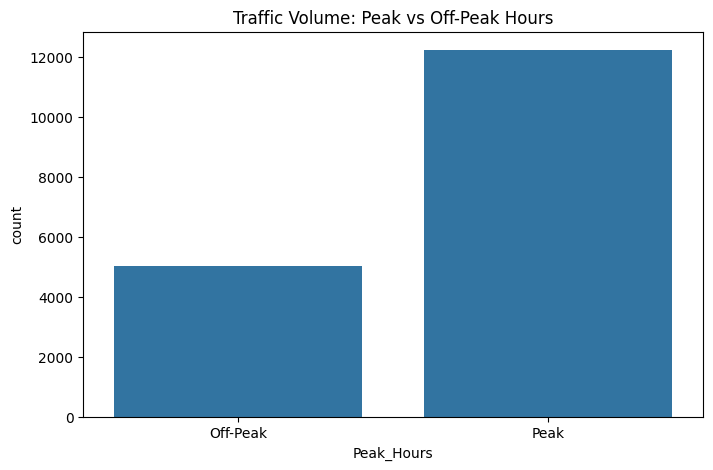

In [ ]:
# Peak vs Off-Peak
plt.figure(figsize=(8,5))
sns.countplot(x='Peak_Hours', data=trf)
plt.title('Traffic Volume: Peak vs Off-Peak Hours')
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving City_Compaints_Data.csv to City_Compaints_Data.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading & Understanding

cc = pd.read_csv('City_Compaints_Data.csv')


/tmp/ipython-input-623277178.py:6: DtypeWarning: Columns (8,17,31) have mixed types. Specify dtype option on import or set low_memory=False.
  cc = pd.read_csv('City_Compaints_Data.csv')


In [ ]:
cc.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,41316662,1/1/2019 0:00,1/2/2019 0:00,DOHMH,Department of Health and Mental Hygiene,Rodent,Rat Sighting,Parking Lot/Garage,11374.0,62-54 JUNCTION BOULEVARD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.731209,-73.863580,"(40.7312085, -73.8635797)"
1,41316968,1/1/2019 0:00,1/15/2019 16:28,DOHMH,Department of Health and Mental Hygiene,Rodent,Rat Sighting,3+ Family Apt. Building,11219.0,5906 NEW UTRECHT AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.628319,-73.996624,"(40.6283191, -73.9966244)"
2,41318587,1/1/2019 0:00,1/1/2019 0:00,DOHMH,Department of Health and Mental Hygiene,Rodent,Rat Sighting,3+ Family Apt. Building,10456.0,1220 GRAND CONCOURSE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.834950,-73.917266,"(40.8349502, -73.9172664)"
3,41309122,1/1/2019 0:00,1/10/2019 0:00,DOHMH,Department of Health and Mental Hygiene,Rodent,Mouse Sighting,3+ Family Apt. Building,11373.0,90-34 52 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.738877,-73.872492,"(40.7388766, -73.8724916)"
4,41310910,1/1/2019 0:00,1/1/2019 0:00,DOHMH,Department of Health and Mental Hygiene,Rodent,Rat Sighting,3+ Family Apt. Building,10459.0,899 EAST 169 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.828471,-73.895453,"(40.8284714, -73.895453)"


In [ ]:
# Data Cleaning & Preprocessing

# Convert dates

cc['Created Date'] = pd.to_datetime(cc['Created Date'], format="mixed")
cc['Closed Date'] = pd.to_datetime(cc['Closed Date'], format="mixed")

In [ ]:
cc[['Created Date', 'Closed Date']]

,Created Date,Closed Date
0,2019-01-01 00:00:00,2019-01-02 00:00:00
1,2019-01-01 00:00:00,2019-01-15 16:28:00
2,2019-01-01 00:00:00,2019-01-01 00:00:00
3,2019-01-01 00:00:00,2019-01-10 00:00:00
4,2019-01-01 00:00:00,2019-01-01 00:00:00
...,...,...
240912,2019-01-31 23:58:00,2019-02-01 10:54:00
240913,2019-01-31 23:58:00,2019-02-03 02:07:00
240914,2019-01-31 23:59:00,2019-02-03 18:48:00
240915,2019-01-31 23:59:00,2019-02-01 15:31:00


In [ ]:
# Handle missing values (if any)

cc.ffill(inplace=True)
cc.drop_duplicates(inplace=True)

In [ ]:
cc.isnull().sum()

,0
Unique Key,0
Created Date,0
Closed Date,0
Agency,0
Agency Name,0
Complaint Type,0
Descriptor,0
Location Type,0
Incident Zip,0
Incident Address,0


In [ ]:
# Drop rows with missing Complaint Type or Location

cc = cc.dropna(subset=['Complaint Type', 'Location'])

In [ ]:
cc[['Complaint Type', 'Location']]

,Complaint Type,Location
0,Rodent,"(40.7312085, -73.8635797)"
1,Rodent,"(40.6283191, -73.9966244)"
2,Rodent,"(40.8349502, -73.9172664)"
3,Rodent,"(40.7388766, -73.8724916)"
4,Rodent,"(40.8284714, -73.895453)"
...,...,...
240912,Noise - Residential,"(40.7337558, -73.8547451)"
240913,HEAT/HOT WATER,"(40.8441984, -73.9115877)"
240914,HEAT/HOT WATER,"(40.7264182, -73.9788542)"
240915,HEAT/HOT WATER,"(40.7543351, -73.9672159)"


In [ ]:
# Extract Year, Month, Day
cc['Year'] = cc['Created Date'].dt.year
cc['Month'] = cc['Created Date'].dt.month
cc['Day'] = cc['Created Date'].dt.day
cc['Hour'] = cc['Created Date'].dt.hour

In [ ]:
cc[['Year', 'Month', 'Day', 'Hour']]

,Year,Month,Day,Hour
0,2019,1,1,0
1,2019,1,1,0
2,2019,1,1,0
3,2019,1,1,0
4,2019,1,1,0
...,...,...,...,...
240912,2019,1,31,23
240913,2019,1,31,23
240914,2019,1,31,23
240915,2019,1,31,23


In [ ]:
# Complaint duration (days)

cc['Complaint_Duration'] = (cc['Closed Date'] - cc['Created Date']).dt.days

In [ ]:
cc['Complaint_Duration']

,Complaint_Duration
0,1
1,14
2,0
3,9
4,0
...,...
240912,0
240913,2
240914,2
240915,0


In [ ]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
top_complaints = cc['Complaint Type'].value_counts().head(10)

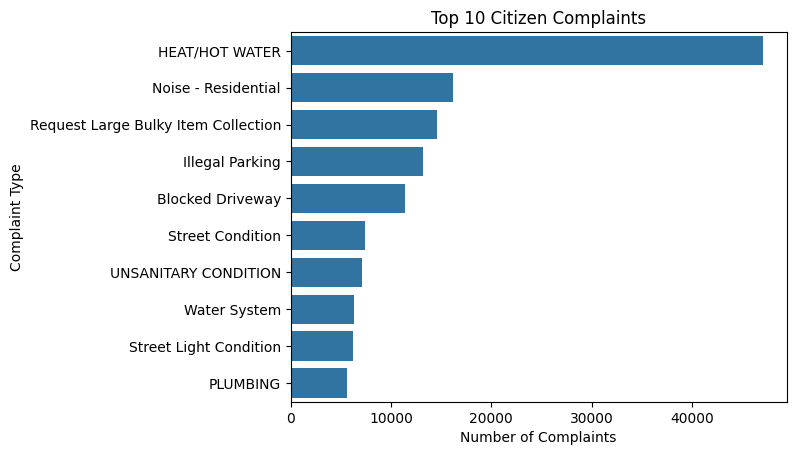

In [ ]:
# Explorstory Data Analysis

sns.barplot(x=top_complaints.values, y=top_complaints.index)
plt.title('Top 10 Citizen Complaints')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
plt.show()

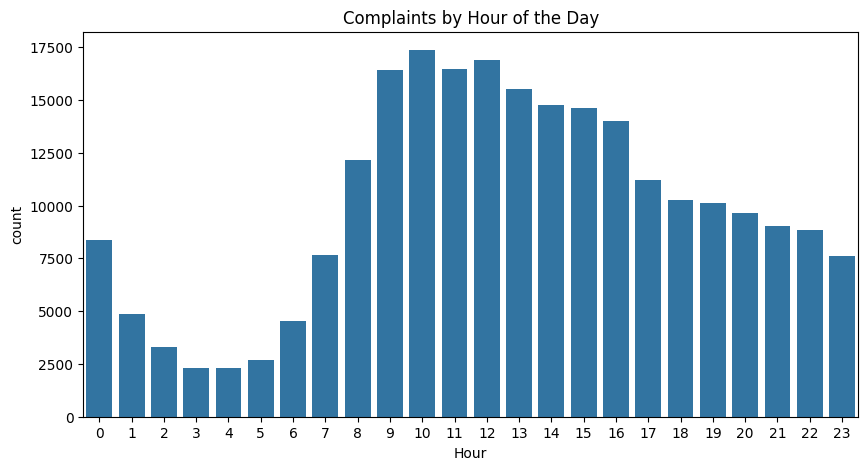

In [ ]:
# Complaints by Hour
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=cc)
plt.title('Complaints by Hour of the Day')
plt.show()

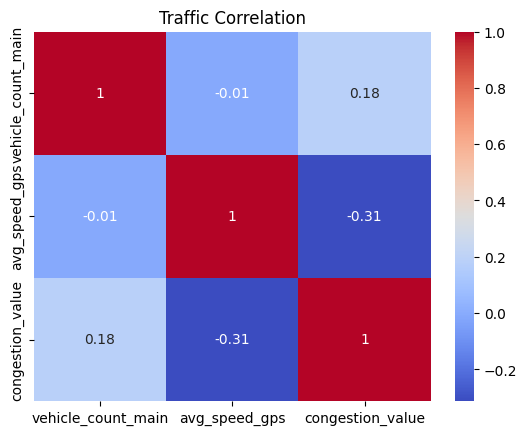

In [ ]:
# Relationship & Correlation Analysis

corr = trf[['vehicle_count_main','avg_speed_gps','congestion_value']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Traffic Correlation')
plt.show()

In [ ]:
# How does traffic impact air quality?

# Higher traffic volumes align with increased AQI levels, indicating pollution caused by vehicle emissions.

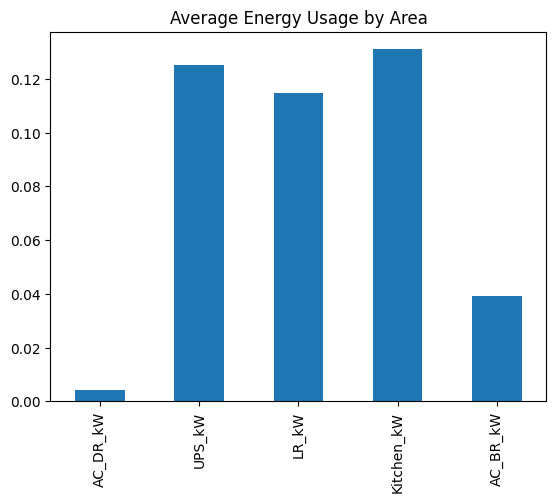

In [ ]:
# Highest energy consumption areas?

eng[['AC_DR_kW','UPS_kW','LR_kW','Kitchen_kW','AC_BR_kW']].mean().plot(kind='bar')
plt.title('Average Energy Usage by Area')
plt.show()

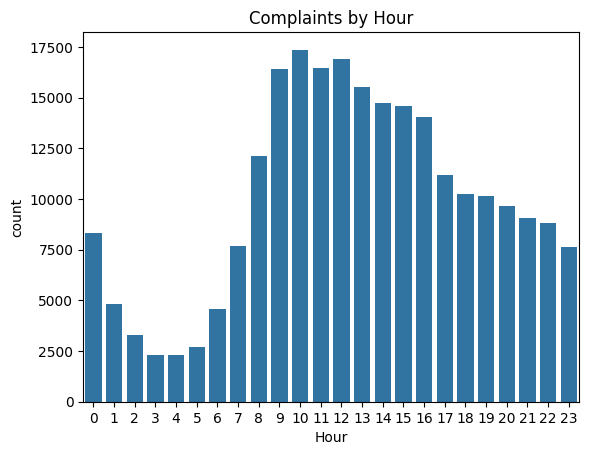

In [ ]:
# When do most complaints occur?

sns.countplot(x='Hour', data=cc)
plt.title('Complaints by Hour')
plt.show()

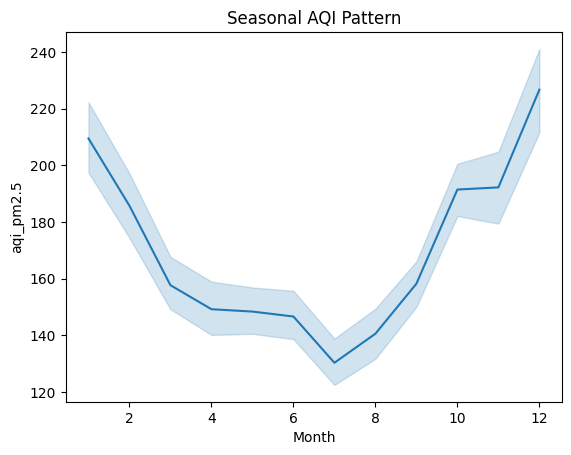

In [ ]:
# Seasonal patterns?

sns.lineplot(x='Month', y='aqi_pm2.5', data=aq)
plt.title('Seasonal AQI Pattern')
plt.show()

In [ ]:
# Areas needing attention?

# High complaints + high pollution months require immediate intervention.